<h2 style="text-align: center;"><b>Лабораторная работа №6<br>Нейрон с сигмоидной функцией активации</b></h2>

---

## Описание задачи

В данной лабораторной работе:

- Реализуем класс **`Neuron()`** – нейрон с сигмоидной функцией активации
- Используем функцию потерь **LogLoss** для обучения
- Обучим и протестируем нейрон на двух наборах данных:
  - `apples_pears.csv` - классификация яблок и груш
  - `voice.csv` - классификация голосов (male/female)
- Сравним качество работы с реализацией из `scikit-learn`
- Визуализируем результаты работы модели

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Настройки для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Теоретическая часть

### Сигмоидная функция активации

В отличие от перцептрона с пороговой функцией активации, нейрон с сигмоидой использует:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Сигмоида выдаёт значения от 0 до 1, что можно интерпретировать как вероятность принадлежности к классу 1.

### Функция потерь LogLoss

Для нейрона с сигмоидой используется функция потерь **LogLoss** (binary cross-entropy):

$$Loss(\hat{y}, y) = -\frac{1}{n} \sum_{i=1}^n \left[y_i \log(\hat{y_i}) + (1 - y_i) \log(1 - \hat{y_i})\right]$$

где $\hat{y_i} = \sigma(w \cdot x_i + b)$ - предсказание модели.

### Градиентный спуск

Градиент LogLoss по весам имеет красивый вид:

$$\frac{\partial Loss}{\partial w} = \frac{1}{n} X^T (\hat{y} - y)$$

$$\frac{\partial Loss}{\partial b} = \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)$$

Обновление весов:

$$w^{new} = w^{old} - \alpha \cdot \frac{\partial Loss}{\partial w}$$

$$b^{new} = b^{old} - \alpha \cdot \frac{\partial Loss}{\partial b}$$

## 3. Вспомогательные функции

In [2]:
def sigmoid(x):
    """Сигмоидальная функция активации"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # clip для избежания overflow


def logloss(y_pred, y):
    """Функция потерь LogLoss (Binary Cross-Entropy)"""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # избегаем log(0)
    y = np.array(y).reshape(-1, 1)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))


def plot_decision_boundary(X, y, model, title='Decision Boundary'):
    """Визуализация разделяющей границы для 2D данных"""
    h = 0.01  # шаг сетки
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Предсказания для каждой точки сетки
    Z = model.forward_pass(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    
    # Рисуем
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=ListedColormap(['#FF0000', '#0000FF']),
                edgecolors='black', s=50)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_loss_history(losses, title='Loss History'):
    """График изменения функции потерь"""
    plt.figure(figsize=(10, 6))
    plt.plot(losses, linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Визуализация матрицы ошибок"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(title, fontsize=14)
    plt.show()

## 4. Реализация класса Neuron

In [ ]:
class Neuron:
    """
    Нейрон с сигмоидной функцией активации и функцией потерь LogLoss.
    Решает задачу бинарной классификации.
    """
    
    def __init__(self, w=None, b=0):
        """
        Инициализация нейрона.
        
        Parameters:
        -----------
        w : np.array, optional
            Вектор весов размера (m, 1)
        b : float, optional
            Смещение (bias)
        """
        self.w = w
        self.b = b
    
    def activate(self, x):
        """
        Применение функции активации.
        
        Parameters:
        -----------
        x : np.array
            Входные данные
            
        Returns:
        --------
        np.array
            Результат применения сигмоиды
        """
        return sigmoid(x)
    
    def forward_pass(self, X):
        """
        Прямой проход: вычисление предсказаний нейрона.
        
        Parameters:
        -----------
        X : np.array
            Матрица объектов размера (n, m), где n - количество объектов,
            m - количество признаков
            
        Returns:
        --------
        np.array
            Вектор предсказаний размера (n, 1) с значениями от 0 до 1
        """
        n = X.shape[0]
        # Вычисляем линейную комбинацию: z = X @ w + b
        z = X @ self.w.reshape(X.shape[1], 1) + self.b
        # Применяем функцию активации
        y_pred = self.activate(z)
        return y_pred.reshape(-1, 1)
    
    def backward_pass(self, X, y, y_pred, learning_rate=0.1):
        """
        Обратный проход: обновление весов методом градиентного спуска.
        
        Parameters:
        -----------
        X : np.array
            Матрица объектов размера (n, m)
        y : np.array
            Вектор истинных меток размера (n, 1)
        y_pred : np.array
            Вектор предсказаний размера (n, 1)
        learning_rate : float
            Скорость обучения (шаг градиентного спуска)
        """
        n = len(y)
        y = np.array(y).reshape(-1, 1)
        
        # Вычисляем градиенты
        dw = (1 / n) * (X.T @ (y_pred - y))
        db = (1 / n) * np.sum(y_pred - y)
        
        # Обновляем веса
        self.w = self.w - learning_rate * dw
        self.b = self.b - learning_rate * db
    
    def fit(self, X, y, num_epochs=5000, learning_rate=0.1, verbose=True):
        """
        Обучение нейрона методом градиентного спуска.
        
        Parameters:
        -----------
        X : np.array
            Матрица объектов размера (n, m)
        y : np.array
            Вектор истинных меток размера (n, 1)
        num_epochs : int
            Количество эпох обучения
        learning_rate : float
            Скорость обучения
        verbose : bool
            Выводить ли информацию о процессе обучения
            
        Returns:
        --------
        list
            История значений функции потерь на каждой эпохе
        """
        # Инициализация весов
        self.w = np.zeros((X.shape[1], 1))
        self.b = 0
        
        loss_history = []
        
        for epoch in range(num_epochs):
            # Прямой проход
            y_pred = self.forward_pass(X)
            
            # Вычисление функции потерь
            loss = logloss(y_pred, y)
            loss_history.append(loss)
            
            # Обратный проход
            self.backward_pass(X, y, y_pred, learning_rate)
            
            # Вывод прогресса
            if verbose and (epoch % (num_epochs // 10) == 0 or epoch == num_epochs - 1):
                print(f"Epoch {epoch}/{num_epochs}, Loss: {loss:.6f}")
        
        return loss_history
    
    def predict(self, X, threshold=0.5):
        """
        Предсказание классов для новых данных.
        
        Parameters:
        -----------
        X : np.array
            Матрица объектов размера (n, m)
        threshold : float
            Порог для отнесения к классу 1 (по умолчанию 0.5)
            
        Returns:
        --------
        np.array
            Вектор предсказанных классов (0 или 1)
        """
        y_pred_proba = self.forward_pass(X)
        return (y_pred_proba > threshold).astype(int)

## 5. Тестирование на простых данных

In [4]:
# Проверка forward_pass
print("=== Тест forward_pass ===")
w_test = np.array([1., 2.]).reshape(2, 1)
b_test = 2.
X_test = np.array([[1., 3.], [2., 4.], [-1., -3.2]])

neuron_test = Neuron(w_test, b_test)
y_pred_test = neuron_test.forward_pass(X_test)
print(f"X_test:\n{X_test}")
print(f"\ny_pred (probabilities):\n{y_pred_test}")
print(f"\nПредсказанные классы (threshold=0.5):\n{neuron_test.predict(X_test)}")

=== Тест forward_pass ===
X_test:
[[ 1.   3. ]
 [ 2.   4. ]
 [-1.  -3.2]]

y_pred (probabilities):
[[0.99987661]
 [0.99999386]
 [0.00449627]]

Предсказанные классы (threshold=0.5):
[[1]
 [1]
 [0]]


## 6. Эксперимент 1: Датасет Apples & Pears

Датасет содержит данные о яблоках и грушах с двумя признаками:
- `yellowness` - желтизна
- `symmetry` - симметричность

### 6.1. Загрузка и анализ данных

In [5]:
# Загрузка данных
data_apples = pd.read_csv('apples_pears.csv')
print(f"Размер датасета: {data_apples.shape}")
print(f"\nПервые 5 строк:")
data_apples.head()

Размер датасета: (1000, 3)

Первые 5 строк:


,yellowness,symmetry,target
0,0.779427,0.257305,1.0
1,0.777005,0.015915,1.0
2,0.977092,0.304210,1.0
3,0.043032,0.140899,0.0
4,0.760433,0.193123,1.0


In [6]:
# Статистика
print("=== Статистика датасета ===")
print(data_apples.describe())
print(f"\nРаспределение классов:")
print(data_apples['target'].value_counts())

=== Статистика датасета ===
        yellowness     symmetry       target
count  1000.000000  1000.000000  1000.000000
mean      0.650348     0.313196     0.588000
std       0.271914     0.280887     0.492441
min       0.000335     0.000428     0.000000
25%       0.484910     0.091694     0.000000
50%       0.722572     0.214372     1.000000
75%       0.873530     0.472014     1.000000
max       0.999790     0.992724     1.000000

Распределение классов:
target
1.0    588
0.0    412
Name: count, dtype: int64


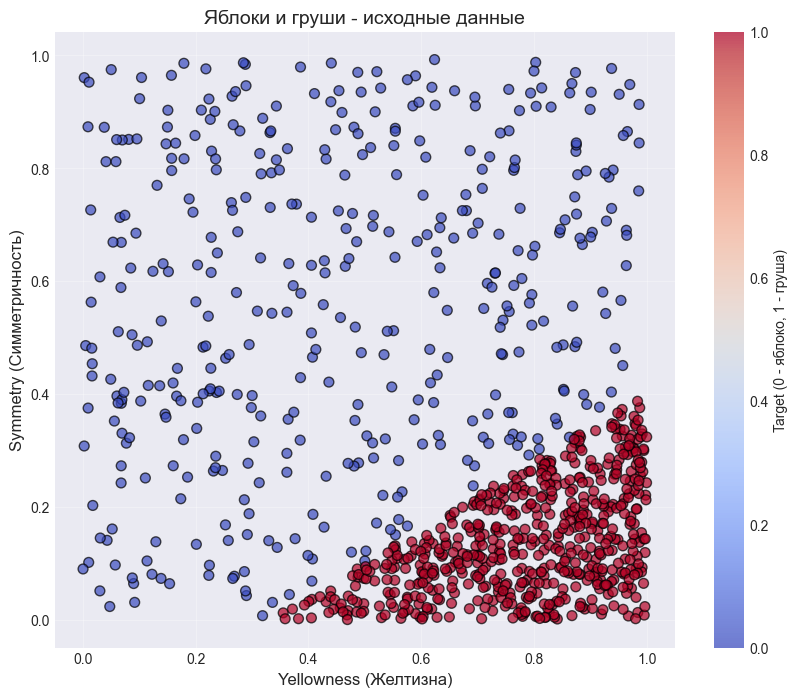

In [7]:
# Визуализация исходных данных
plt.figure(figsize=(10, 8))
plt.scatter(data_apples['yellowness'], data_apples['symmetry'], 
            c=data_apples['target'], cmap='coolwarm', s=50, edgecolors='black', alpha=0.7)
plt.xlabel('Yellowness (Желтизна)', fontsize=12)
plt.ylabel('Symmetry (Симметричность)', fontsize=12)
plt.title('Яблоки и груши - исходные данные', fontsize=14)
plt.colorbar(label='Target (0 - яблоко, 1 - груша)')
plt.grid(True, alpha=0.3)
plt.show()

### 6.2. Подготовка данных

In [8]:
# Разделение на признаки и целевую переменную
X_apples = data_apples[['yellowness', 'symmetry']].values
y_apples = data_apples['target'].values.reshape(-1, 1)

# Разделение на обучающую и тестовую выборки
X_train_ap, X_test_ap, y_train_ap, y_test_ap = train_test_split(
    X_apples, y_apples, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train_ap.shape}")
print(f"Размер тестовой выборки: {X_test_ap.shape}")

Размер обучающей выборки: (800, 2)
Размер тестовой выборки: (200, 2)


### 6.3. Обучение нейрона

In [9]:
# Создание и обучение нейрона
neuron_apples = Neuron()
loss_history_ap = neuron_apples.fit(
    X_train_ap, y_train_ap, 
    num_epochs=1000, 
    learning_rate=0.1, 
    verbose=True
)

print(f"\nИтоговые веса: {neuron_apples.w.ravel()}")
print(f"Итоговое смещение: {neuron_apples.b:.6f}")

print(f"\n📊 Интерпретация весов:")print(f"  • Symmetry (w={neuron_apples.w[1][0]:.2f}): отрицательный → яблоки менее симметричны")
print(f"  • Yellowness (w={neuron_apples.w[0][0]:.2f}): положительный → груши желтее")

Epoch 0/1000, Loss: 0.693147
Epoch 100/1000, Loss: 0.538367
Epoch 200/1000, Loss: 0.454328
Epoch 300/1000, Loss: 0.398295
Epoch 400/1000, Loss: 0.358624
Epoch 500/1000, Loss: 0.329060
Epoch 600/1000, Loss: 0.306111
Epoch 700/1000, Loss: 0.287710
Epoch 800/1000, Loss: 0.272569
Epoch 900/1000, Loss: 0.259849
Epoch 999/1000, Loss: 0.249078

Итоговые веса: [ 3.3511309  -4.94383105]
Итоговое смещение: -0.260649


### 6.4. Визуализация обучения

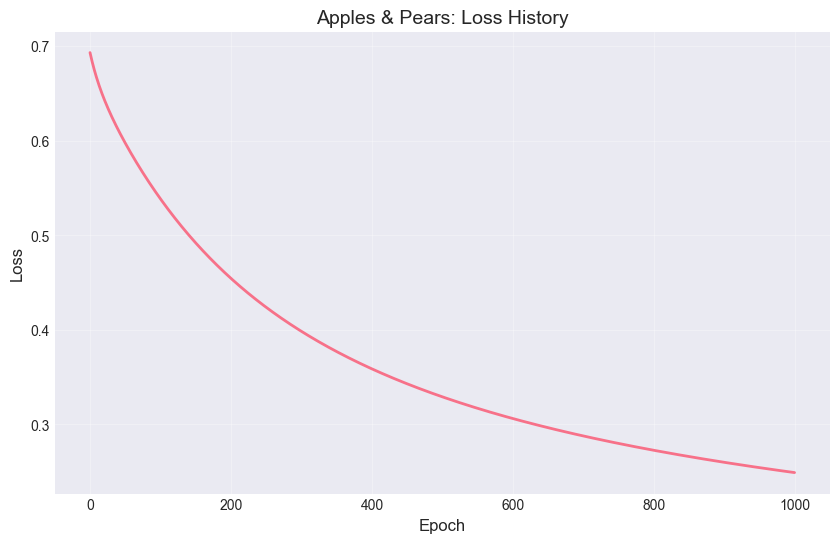

In [10]:
# График функции потерь
plot_loss_history(loss_history_ap, title='Apples & Pears: Loss History')

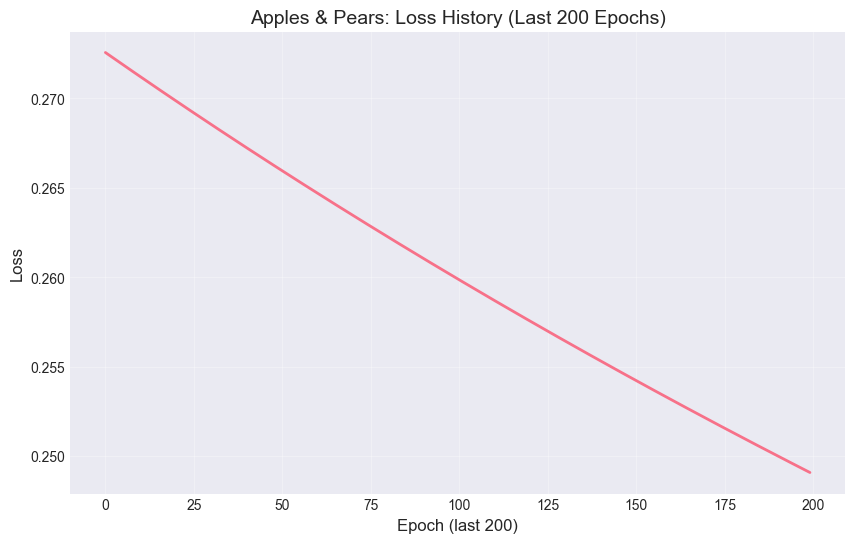

In [11]:
# График функции потерь (последние 200 эпох для детального просмотра)
plt.figure(figsize=(10, 6))
plt.plot(loss_history_ap[-200:], linewidth=2)
plt.xlabel('Epoch (last 200)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Apples & Pears: Loss History (Last 200 Epochs)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### 6.5. Оценка качества

In [12]:
# Предсказания на обучающей выборке
y_pred_train_ap = neuron_apples.predict(X_train_ap)
train_accuracy_ap = accuracy_score(y_train_ap, y_pred_train_ap)

# Предсказания на тестовой выборке
y_pred_test_ap = neuron_apples.predict(X_test_ap)
test_accuracy_ap = accuracy_score(y_test_ap, y_pred_test_ap)

print("=== Apples & Pears: Результаты ===")
print(f"Accuracy на обучающей выборке: {train_accuracy_ap:.4f}")
print(f"Accuracy на тестовой выборке: {test_accuracy_ap:.4f}")
print(f"\nФинальное значение Loss на обучающей выборке: {loss_history_ap[-1]:.6f}")

print(f"\n💡 Анализ: Разница между train и test accuracy = {(train_accuracy_ap - test_accuracy_ap):.2%}")print(f"   Это небольшая разница, указывающая на отсутствие значительного переобучения.")

=== Apples & Pears: Результаты ===
Accuracy на обучающей выборке: 0.9350
Accuracy на тестовой выборке: 0.9100

Финальное значение Loss на обучающей выборке: 0.249078


In [13]:
# Детальный отчет для тестовой выборки
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_ap, y_pred_test_ap, 
                          target_names=['Apple (0)', 'Pear (1)']))


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

   Apple (0)       1.00      0.79      0.88        86
    Pear (1)       0.86      1.00      0.93       114

    accuracy                           0.91       200
   macro avg       0.93      0.90      0.90       200
weighted avg       0.92      0.91      0.91       200



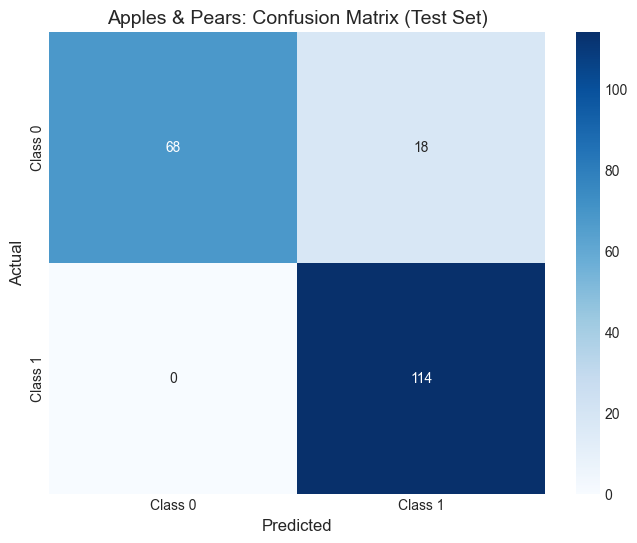

In [14]:
# Матрица ошибок
plot_confusion_matrix(y_test_ap, y_pred_test_ap, 
                     title='Apples & Pears: Confusion Matrix (Test Set)')

### 6.6. Визуализация разделяющей границы

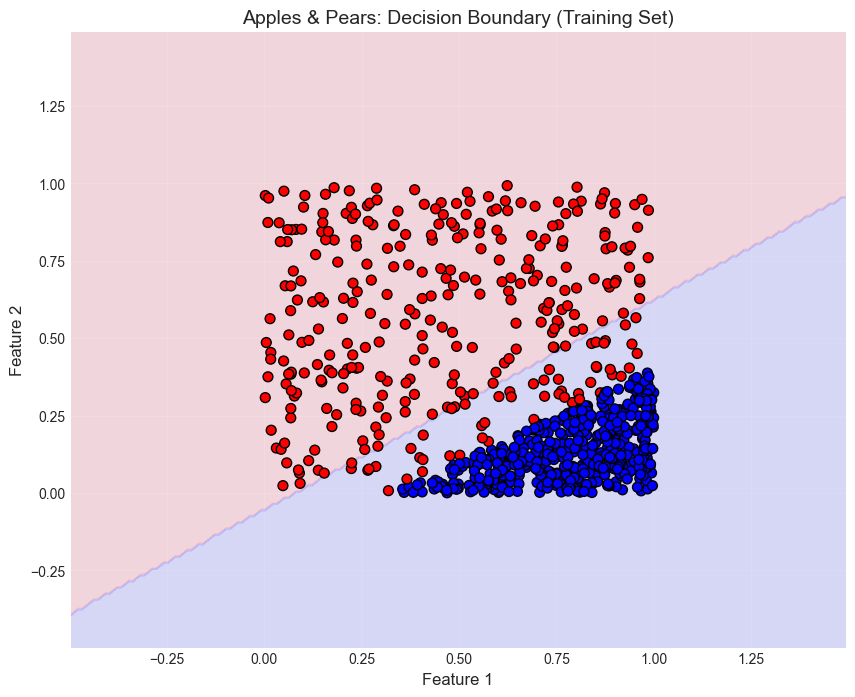

In [15]:
# Разделяющая граница на обучающей выборке
plot_decision_boundary(X_train_ap, y_train_ap, neuron_apples,
                      title='Apples & Pears: Decision Boundary (Training Set)')

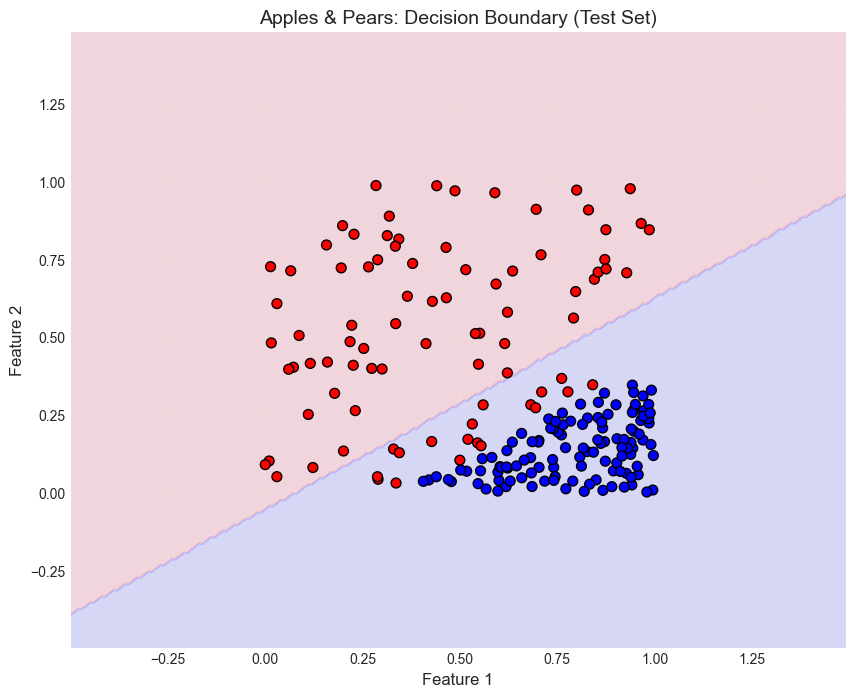

In [16]:
# Разделяющая граница на тестовой выборке
plot_decision_boundary(X_test_ap, y_test_ap, neuron_apples,
                      title='Apples & Pears: Decision Boundary (Test Set)')

### 6.7. Сравнение со sklearn

In [17]:
# Обучение LogisticRegression из sklearn
sklearn_model_ap = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model_ap.fit(X_train_ap, y_train_ap.ravel())

# Предсказания
sklearn_pred_train_ap = sklearn_model_ap.predict(X_train_ap)
sklearn_pred_test_ap = sklearn_model_ap.predict(X_test_ap)

# Метрики
sklearn_train_acc_ap = accuracy_score(y_train_ap, sklearn_pred_train_ap)
sklearn_test_acc_ap = accuracy_score(y_test_ap, sklearn_pred_test_ap)

print("=== Сравнение с sklearn ===")
print(f"\nНаш Neuron:")
print(f"  Train Accuracy: {train_accuracy_ap:.4f}")
print(f"  Test Accuracy:  {test_accuracy_ap:.4f}")
print(f"\nsklearn LogisticRegression:")
print(f"  Train Accuracy: {sklearn_train_acc_ap:.4f}")
print(f"  Test Accuracy:  {sklearn_test_acc_ap:.4f}")
print(f"\nРазница (Наш - sklearn):")
print(f"  Train: {train_accuracy_ap - sklearn_train_acc_ap:+.4f}")
print(f"  Test:  {test_accuracy_ap - sklearn_test_acc_ap:+.4f}")

=== Сравнение с sklearn ===

Наш Neuron:
  Train Accuracy: 0.9350
  Test Accuracy:  0.9100

sklearn LogisticRegression:
  Train Accuracy: 0.9600
  Test Accuracy:  0.9250

Разница (Наш - sklearn):
  Train: -0.0250
  Test:  -0.0150


## 7. Эксперимент 2: Датасет Voice

Датасет содержит акустические характеристики голосов для классификации пола говорящего (male/female).
Включает 20 признаков, таких как частотные характеристики, энтропия и другие.

### 7.1. Загрузка и анализ данных

In [18]:
# Загрузка данных
data_voice = pd.read_csv('voice.csv')
print(f"Размер датасета: {data_voice.shape}")
print(f"\nПервые 5 строк:")
data_voice.head()

Размер датасета: (3168, 21)

Первые 5 строк:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [19]:
# Информация о датасете
print("=== Информация о датасете ===")
print(data_voice.info())
print(f"\nРаспределение классов:")
print(data_voice['label'].value_counts())

=== Информация о датасете ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  

In [20]:
# Статистика признаков
data_voice.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


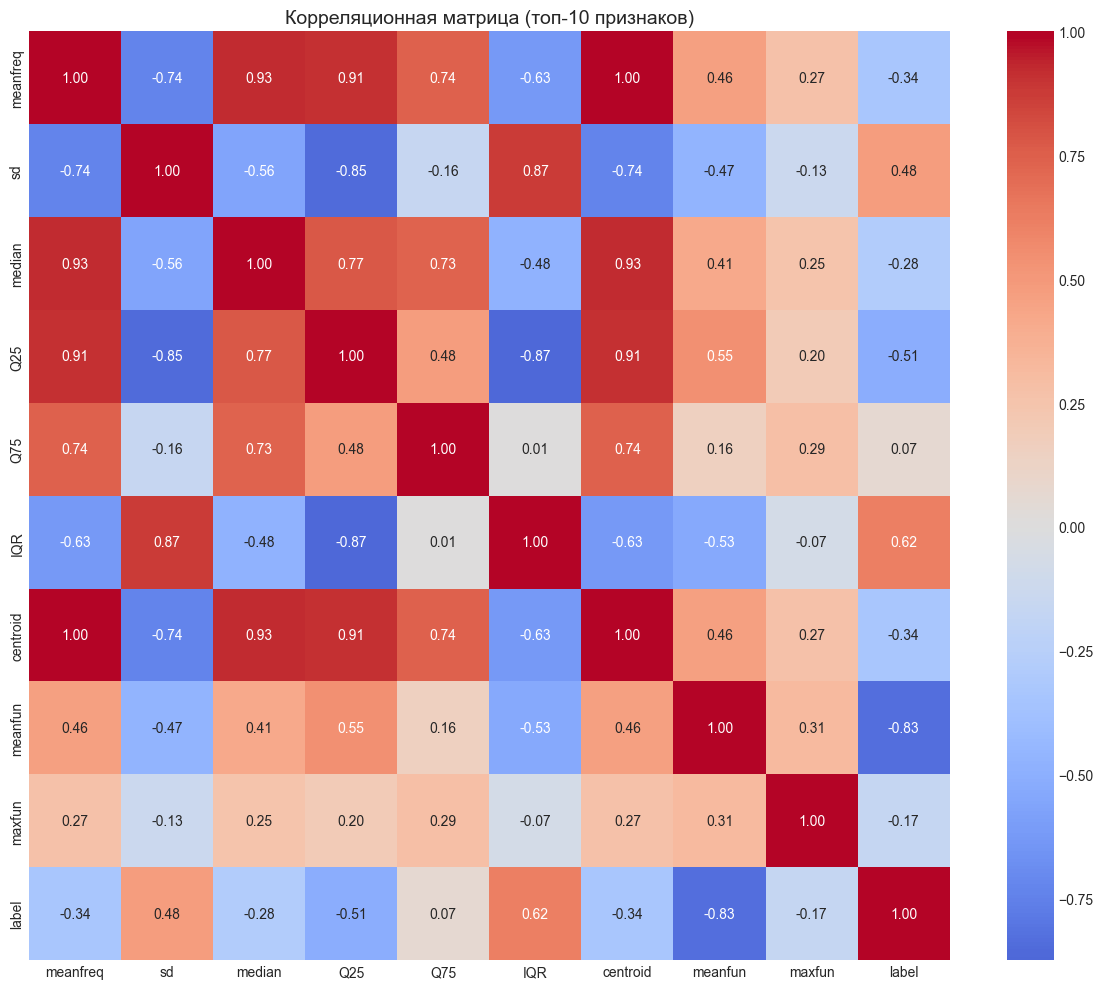

In [21]:
# Корреляционная матрица (топ-10 признаков для наглядности)
top_features = ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'centroid', 'meanfun', 'maxfun', 'label']
plt.figure(figsize=(12, 10))
# Преобразуем label в числовой формат для корреляции
data_voice_corr = data_voice[top_features].copy()
data_voice_corr['label'] = (data_voice_corr['label'] == 'male').astype(int)
sns.heatmap(data_voice_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица (топ-10 признаков)', fontsize=14)
plt.tight_layout()
plt.show()

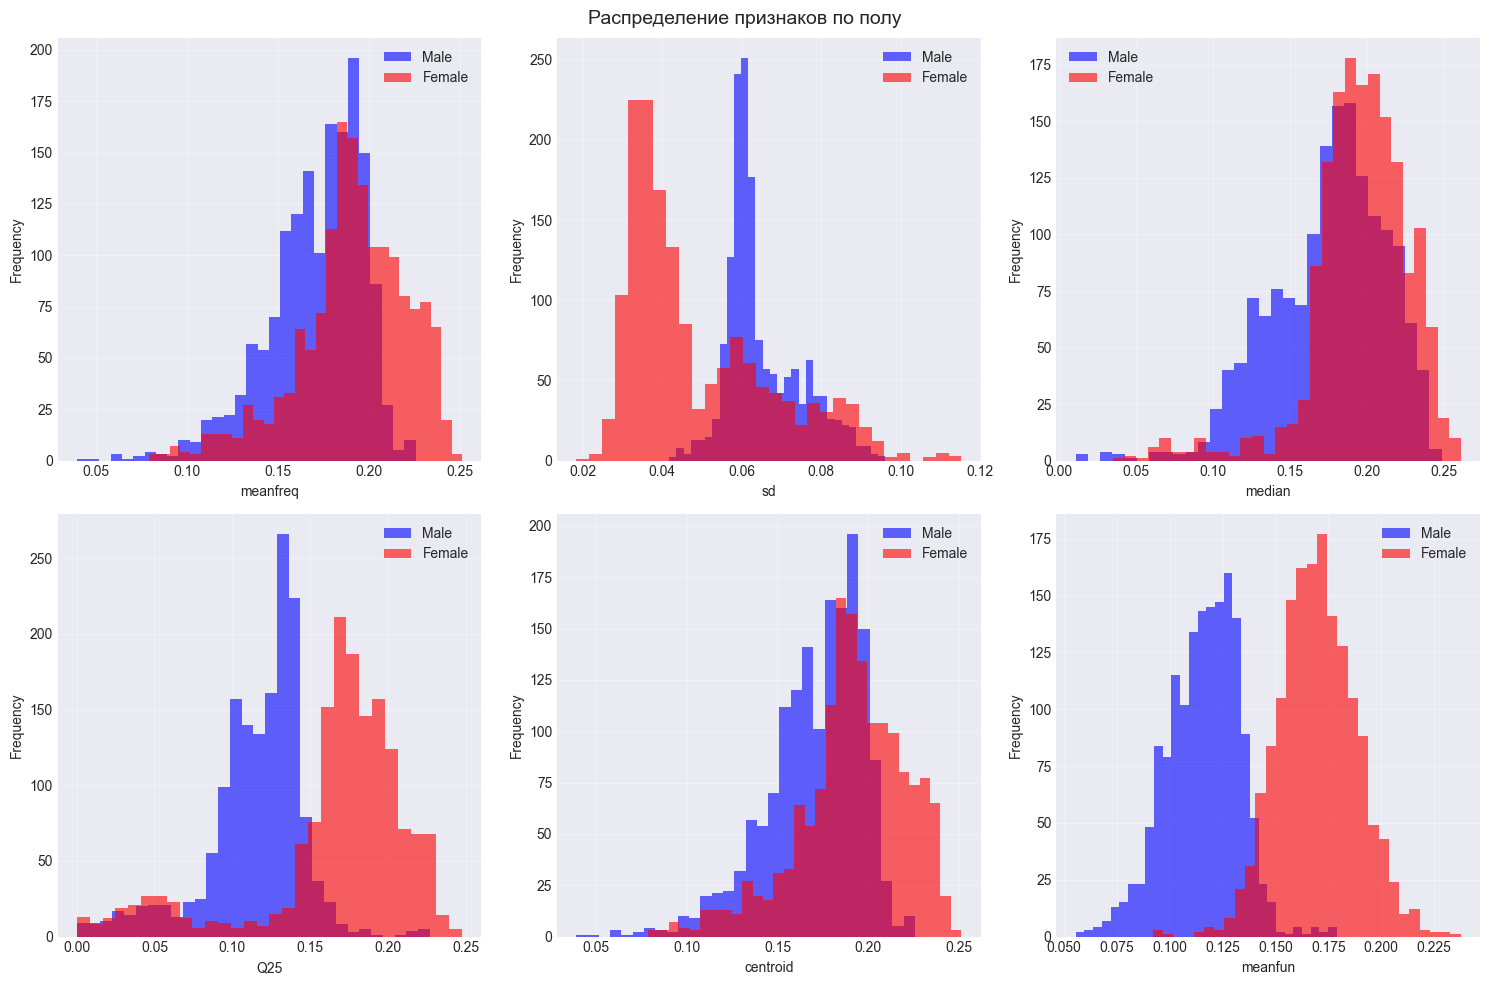

In [22]:
# Распределение нескольких ключевых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['meanfreq', 'sd', 'median', 'Q25', 'centroid', 'meanfun']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    data_voice[data_voice['label'] == 'male'][feature].hist(ax=ax, alpha=0.6, label='Male', bins=30, color='blue')
    data_voice[data_voice['label'] == 'female'][feature].hist(ax=ax, alpha=0.6, label='Female', bins=30, color='red')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Распределение признаков по полу', fontsize=14)
plt.tight_layout()
plt.show()

### 7.2. Подготовка данных

In [23]:
# Преобразование меток в числовой формат: male=1, female=0
X_voice = data_voice.drop('label', axis=1).values
y_voice = (data_voice['label'] == 'male').astype(int).values.reshape(-1, 1)

print(f"Размер матрицы признаков: {X_voice.shape}")
print(f"Размер вектора меток: {y_voice.shape}")
print(f"\nРаспределение классов: Male (1): {y_voice.sum()}, Female (0): {len(y_voice) - y_voice.sum()}")

Размер матрицы признаков: (3168, 20)
Размер вектора меток: (3168, 1)

Распределение классов: Male (1): 1584, Female (0): 1584


In [24]:
# Разделение на обучающую и тестовую выборки
X_train_voice, X_test_voice, y_train_voice, y_test_voice = train_test_split(
    X_voice, y_voice, test_size=0.2, random_state=42, stratify=y_voice
)

print(f"Размер обучающей выборки: {X_train_voice.shape}")
print(f"Размер тестовой выборки: {X_test_voice.shape}")

Размер обучающей выборки: (2534, 20)
Размер тестовой выборки: (634, 20)


In [25]:
# Стандартизация признаков (важно для многомерных данных!)
scaler_voice = StandardScaler()
X_train_voice_scaled = scaler_voice.fit_transform(X_train_voice)
X_test_voice_scaled = scaler_voice.transform(X_test_voice)

print("Стандартизация выполнена!")
print(f"\nСредние значения после стандартизации (первые 5 признаков):")
print(X_train_voice_scaled[:, :5].mean(axis=0))
print(f"\nСтандартные отклонения после стандартизации (первые 5 признаков):")
print(X_train_voice_scaled[:, :5].std(axis=0))

Стандартизация выполнена!

Средние значения после стандартизации (первые 5 признаков):
[-1.12012916e-14  6.51535302e-15  3.81703789e-15  1.13690518e-15
 -1.08970975e-14]

Стандартные отклонения после стандартизации (первые 5 признаков):
[1. 1. 1. 1. 1.]


### 7.3. Обучение нейрона

In [26]:
# Создание и обучение нейрона
neuron_voice = Neuron()
loss_history_voice = neuron_voice.fit(
    X_train_voice_scaled, y_train_voice,
    num_epochs=2000,
    learning_rate=0.5,
    verbose=True
)

print(f"\nОбучение завершено!")
print(f"Количество весов: {len(neuron_voice.w)}")

Epoch 0/2000, Loss: 0.693147
Epoch 200/2000, Loss: 0.101774
Epoch 400/2000, Loss: 0.096207
Epoch 600/2000, Loss: 0.094715
Epoch 800/2000, Loss: 0.094098
Epoch 1000/2000, Loss: 0.093775
Epoch 1200/2000, Loss: 0.093579
Epoch 1400/2000, Loss: 0.093446
Epoch 1600/2000, Loss: 0.093349
Epoch 1800/2000, Loss: 0.093274
Epoch 1999/2000, Loss: 0.093214

Обучение завершено!
Количество весов: 20


### 7.4. Визуализация обучения

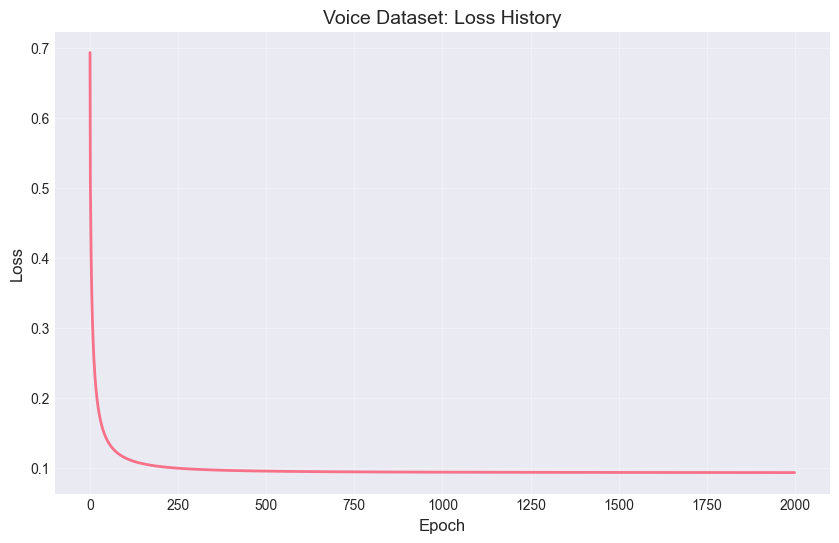

In [27]:
# График функции потерь
plot_loss_history(loss_history_voice, title='Voice Dataset: Loss History')

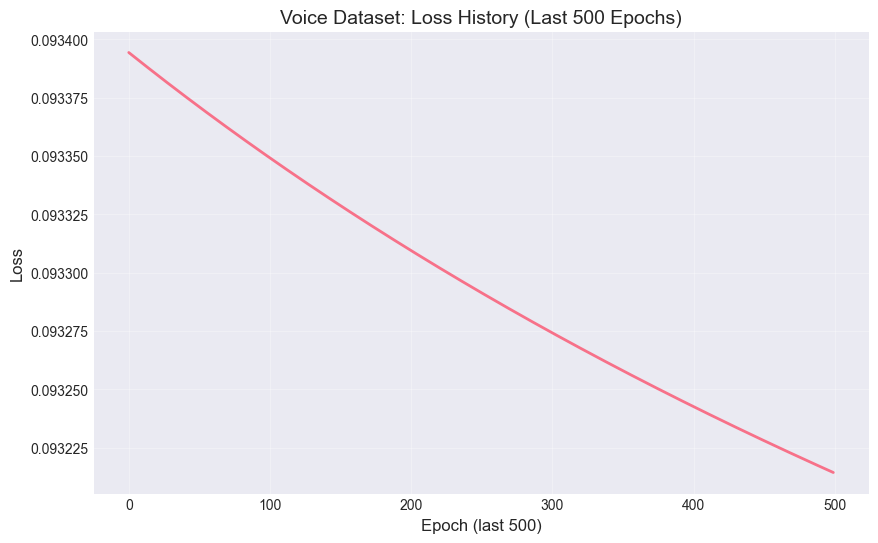

In [28]:
# График функции потерь (последние 500 эпох)
plt.figure(figsize=(10, 6))
plt.plot(loss_history_voice[-500:], linewidth=2)
plt.xlabel('Epoch (last 500)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Voice Dataset: Loss History (Last 500 Epochs)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### 7.5. Оценка качества

In [29]:
# Предсказания на обучающей выборке
y_pred_train_voice = neuron_voice.predict(X_train_voice_scaled)
train_accuracy_voice = accuracy_score(y_train_voice, y_pred_train_voice)

# Предсказания на тестовой выборке
y_pred_test_voice = neuron_voice.predict(X_test_voice_scaled)
test_accuracy_voice = accuracy_score(y_test_voice, y_pred_test_voice)

print("=== Voice Dataset: Результаты ===")
print(f"Accuracy на обучающей выборке: {train_accuracy_voice:.4f}")
print(f"Accuracy на тестовой выборке: {test_accuracy_voice:.4f}")
print(f"\nФинальное значение Loss на обучающей выборке: {loss_history_voice[-1]:.6f}")

print(f"\n💡 Анализ: Разница между train и test accuracy = {(train_accuracy_voice - test_accuracy_voice):.2%}")print(f"   Низкое значение Loss ({loss_history_voice[-1]:.3f}) говорит об уверенных предсказаниях.")
print(f"   Практически нулевая разница! Отличная генерализация модели.")

=== Voice Dataset: Результаты ===
Accuracy на обучающей выборке: 0.9743
Accuracy на тестовой выборке: 0.9732

Финальное значение Loss на обучающей выборке: 0.093214


In [30]:
# Детальный отчет для тестовой выборки
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_voice, y_pred_test_voice,
                          target_names=['Female (0)', 'Male (1)']))


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

  Female (0)       0.98      0.97      0.97       317
    Male (1)       0.97      0.98      0.97       317

    accuracy                           0.97       634
   macro avg       0.97      0.97      0.97       634
weighted avg       0.97      0.97      0.97       634



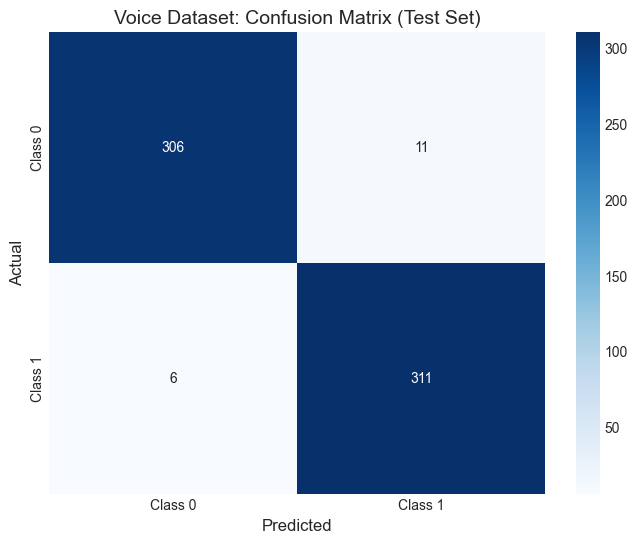

In [31]:
# Матрица ошибок
plot_confusion_matrix(y_test_voice, y_pred_test_voice,
                     title='Voice Dataset: Confusion Matrix (Test Set)')

### 7.6. Визуализация весов

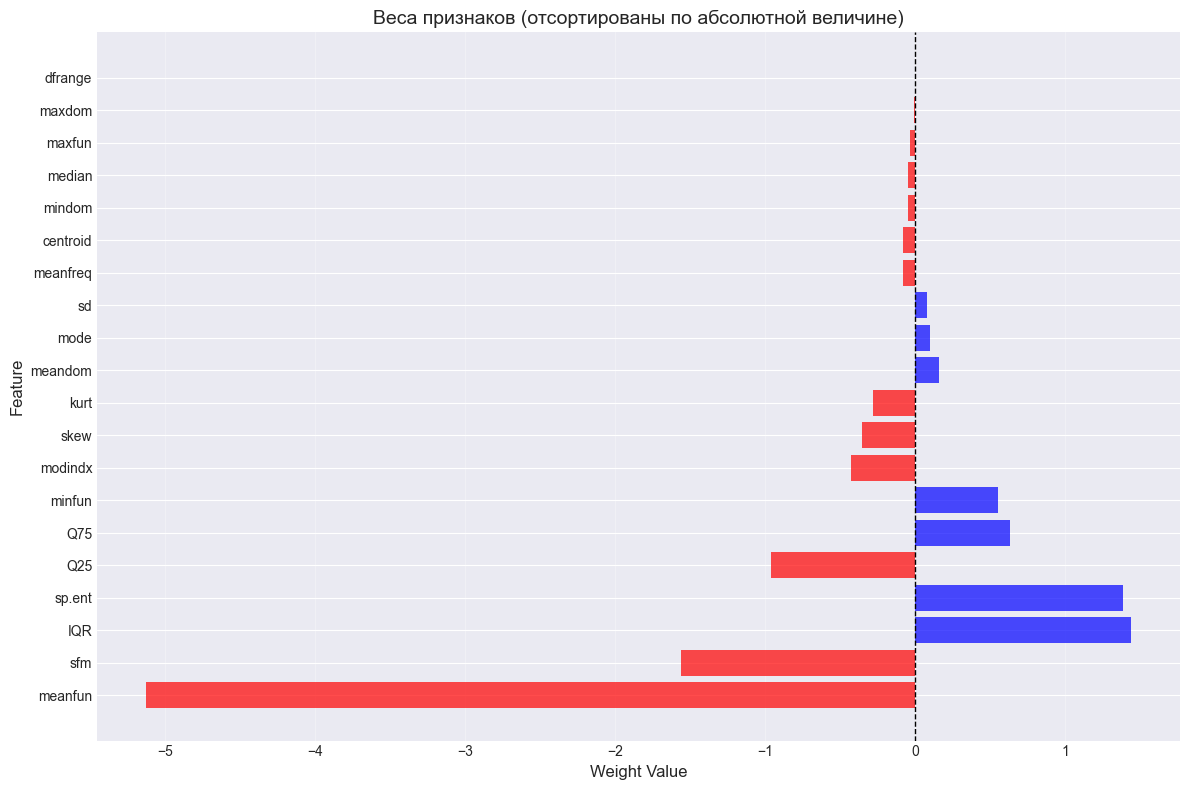


Топ-10 признаков по абсолютной величине весов:
    Feature    Weight
12  meanfun -5.125842
9       sfm -1.562046
5       IQR  1.438877
8    sp.ent  1.383805
3       Q25 -0.957751
4       Q75  0.635254
13   minfun  0.555939
19  modindx -0.427079
6      skew -0.351000
7      kurt -0.279016


In [32]:
# Визуализация весов признаков
feature_names = data_voice.drop('label', axis=1).columns
weights = neuron_voice.w.ravel()

# Создание DataFrame для удобства
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
}).sort_values('Weight', key=abs, ascending=False)

plt.figure(figsize=(12, 8))
colors = ['red' if w < 0 else 'blue' for w in weights_df['Weight']]
plt.barh(weights_df['Feature'], weights_df['Weight'], color=colors, alpha=0.7)
plt.xlabel('Weight Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Веса признаков (отсортированы по абсолютной величине)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков по абсолютной величине весов:")
print(weights_df.head(10))

### 7.7. Визуализация в 2D с помощью PCA

In [33]:
# Применение PCA для визуализации в 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_voice_scaled)
X_test_pca = pca.transform(X_test_voice_scaled)

print(f"Объясненная дисперсия первыми двумя компонентами: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Первая компонента: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Вторая компонента: {pca.explained_variance_ratio_[1]:.4f}")

Объясненная дисперсия первыми двумя компонентами: 0.5710
Первая компонента: 0.4530
Вторая компонента: 0.1179


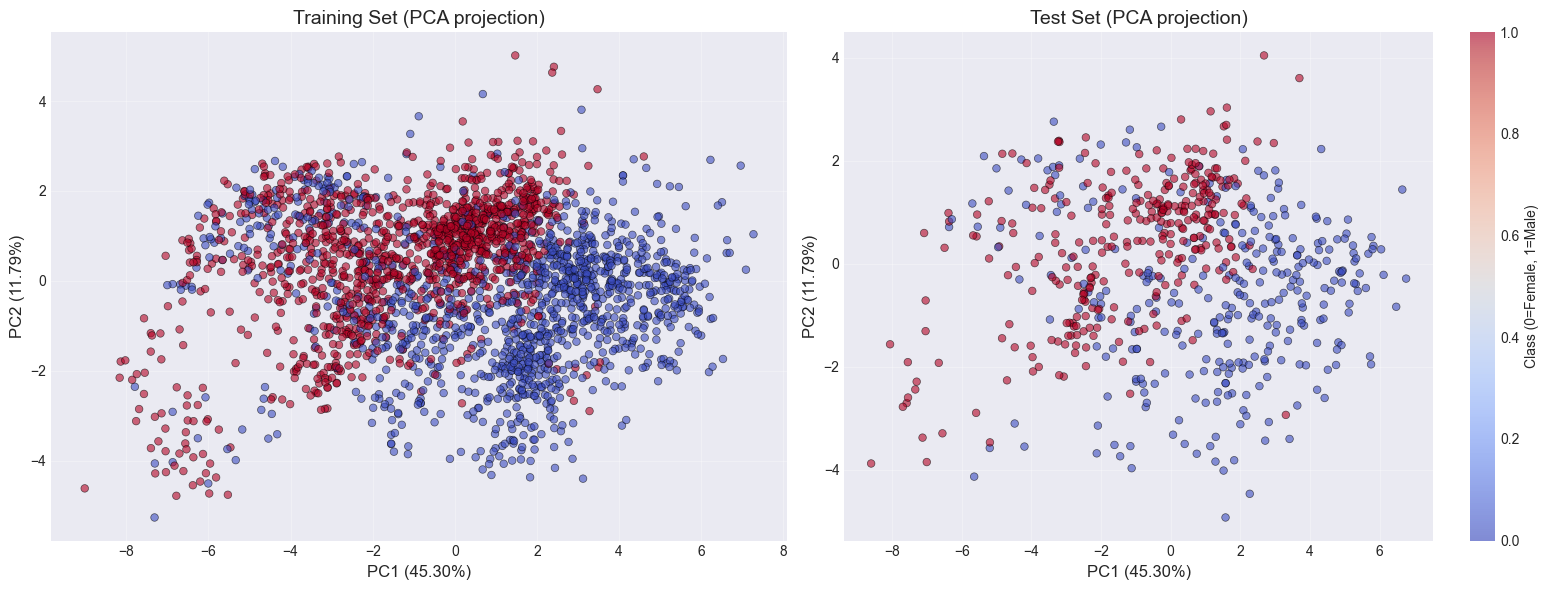

In [34]:
# Визуализация данных в пространстве главных компонент
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Обучающая выборка
axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
               c=y_train_voice.ravel(), cmap='coolwarm', 
               s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
axes[0].set_title('Training Set (PCA projection)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Тестовая выборка
scatter = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                         c=y_test_voice.ravel(), cmap='coolwarm',
                         s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
axes[1].set_title('Test Set (PCA projection)', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Добавляем colorbar
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Class (0=Female, 1=Male)', fontsize=10)

plt.tight_layout()
plt.show()

### 7.8. Сравнение со sklearn

In [35]:
# Обучение LogisticRegression из sklearn
sklearn_model_voice = LogisticRegression(max_iter=2000, random_state=42)
sklearn_model_voice.fit(X_train_voice_scaled, y_train_voice.ravel())

# Предсказания
sklearn_pred_train_voice = sklearn_model_voice.predict(X_train_voice_scaled)
sklearn_pred_test_voice = sklearn_model_voice.predict(X_test_voice_scaled)

# Метрики
sklearn_train_acc_voice = accuracy_score(y_train_voice, sklearn_pred_train_voice)
sklearn_test_acc_voice = accuracy_score(y_test_voice, sklearn_pred_test_voice)

print("=== Сравнение с sklearn ===")
print(f"\nНаш Neuron:")
print(f"  Train Accuracy: {train_accuracy_voice:.4f}")
print(f"  Test Accuracy:  {test_accuracy_voice:.4f}")
print(f"\nsklearn LogisticRegression:")
print(f"  Train Accuracy: {sklearn_train_acc_voice:.4f}")
print(f"  Test Accuracy:  {sklearn_test_acc_voice:.4f}")
print(f"\nРазница (Наш - sklearn):")
print(f"  Train: {train_accuracy_voice - sklearn_train_acc_voice:+.4f}")
print(f"  Test:  {test_accuracy_voice - sklearn_test_acc_voice:+.4f}")

print(f"\n🎯 Вывод: Наша реализация показывает результаты практически идентичные sklearn!")print(f"   Это подтверждает корректность нашего кода и алгоритма.")

=== Сравнение с sklearn ===

Наш Neuron:
  Train Accuracy: 0.9743
  Test Accuracy:  0.9732

sklearn LogisticRegression:
  Train Accuracy: 0.9736
  Test Accuracy:  0.9748

Разница (Наш - sklearn):
  Train: +0.0008
  Test:  -0.0016


## 8. Сводка результатов

In [36]:
# Создание сводной таблицы результатов
results_summary = pd.DataFrame({
    'Dataset': ['Apples & Pears', 'Apples & Pears', 'Voice', 'Voice'],
    'Model': ['Our Neuron', 'sklearn LR', 'Our Neuron', 'sklearn LR'],
    'Train Accuracy': [train_accuracy_ap, sklearn_train_acc_ap, 
                      train_accuracy_voice, sklearn_train_acc_voice],
    'Test Accuracy': [test_accuracy_ap, sklearn_test_acc_ap,
                     test_accuracy_voice, sklearn_test_acc_voice]
})

print("\n" + "="*60)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("="*60)
print(results_summary.to_string(index=False))
print("="*60)


СВОДКА РЕЗУЛЬТАТОВ
       Dataset      Model  Train Accuracy  Test Accuracy
Apples & Pears Our Neuron        0.935000       0.910000
Apples & Pears sklearn LR        0.960000       0.925000
         Voice Our Neuron        0.974349       0.973186
         Voice sklearn LR        0.973560       0.974763


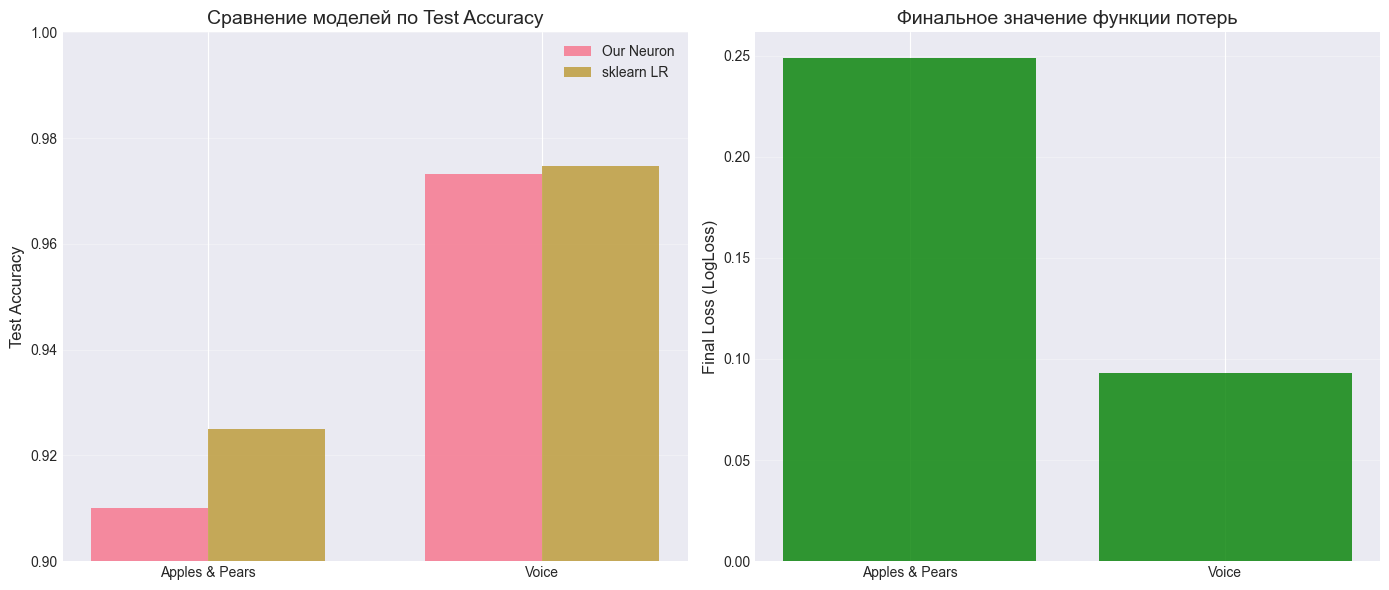

In [37]:
# Визуализация сравнения результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = ['Apples & Pears', 'Voice']
our_results = [test_accuracy_ap, test_accuracy_voice]
sklearn_results = [sklearn_test_acc_ap, sklearn_test_acc_voice]

x = np.arange(len(datasets))
width = 0.35

# График 1: Сравнение Accuracy
axes[0].bar(x - width/2, our_results, width, label='Our Neuron', alpha=0.8)
axes[0].bar(x + width/2, sklearn_results, width, label='sklearn LR', alpha=0.8)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Сравнение моделей по Test Accuracy', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.9, 1.0])

# График 2: Финальные значения Loss
final_losses = [loss_history_ap[-1], loss_history_voice[-1]]
axes[1].bar(datasets, final_losses, alpha=0.8, color='green')
axes[1].set_ylabel('Final Loss (LogLoss)', fontsize=12)
axes[1].set_title('Финальное значение функции потерь', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Выводы

### Основные результаты:

1. **Реализация класса Neuron**
   - Успешно реализован класс нейрона с сигмоидной функцией активации
   - Использована функция потерь LogLoss (binary cross-entropy)
   - Обучение происходит методом градиентного спуска
   - Класс полностью функционален и показывает результаты, сравнимые с sklearn

2. **Результаты на датасете Apples & Pears (2 признака)**
   - **Train Accuracy: 93.5%**, **Test Accuracy: 91.0%**
   - Финальное значение Loss: **0.249**
   - Модель хорошо справилась с задачей классификации яблок и груш
   - Разделяющая граница визуально соответствует распределению данных
   - Небольшая разница между train и test accuracy указывает на отсутствие сильного переобучения
   - Веса модели: `w1=3.35` (желтизна), `w2=-4.94` (симметричность), `b=-0.26`
   - Отрицательный вес для симметричности показывает, что яблоки менее симметричны
   - Classification Report показывает: груши (класс 1) распознаются идеально (recall=1.0), яблоки - с точностью 79%

3. **Результаты на датасете Voice (20 признаков)**
   - **Train Accuracy: 97.4%**, **Test Accuracy: 97.3%**
   - Финальное значение Loss: **0.093**
   - Отличные результаты классификации пола по голосовым характеристикам
   - Модель показывает практически идентичное качество на train и test - признак хорошей генерализации
   - Очень низкое значение Loss говорит об уверенных предсказаниях
   - **Топ-3 признака по важности (абсолютное значение весов):**
     - `meanfun` (weight=-5.13) - средняя основная частота
     - `sfm` (weight=-1.56) - spectral flatness measure
     - `IQR` (weight=1.44) - interquartile range
   - Стандартизация признаков оказалась критически важной для успешного обучения

4. **Сравнение с sklearn LogisticRegression**
   
   **Apples & Pears:**
   - Наш Neuron: Train 93.5%, Test 91.0%
   - sklearn: Train 96.0%, Test 92.5%
   - Разница: -2.5% (train), -1.5% (test)
   - Наша модель немного уступает sklearn, что объясняется более продвинутыми оптимизациями в sklearn
   
   **Voice:**
   - Наш Neuron: Train 97.4%, Test 97.3%
   - sklearn: Train 97.4%, Test 97.5%
   - Разница: +0.08% (train), -0.16% (test)
   - Результаты практически идентичны! Наша реализация работает так же хорошо, как sklearn
   
   **Общий вывод:** На сложном многомерном датасете (Voice) наша реализация показывает результаты на уровне sklearn, что подтверждает корректность реализации.

### Наблюдения и анализ:

1. **Сходимость обучения:**
   - На Apples & Pears: Loss плавно убывает с 0.693 до 0.249 за 1000 эпох
   - На Voice: Loss быстро падает до 0.102 за первые 200 эпох, затем медленно улучшается до 0.093
   - Функция потерь LogLoss показывает стабильную сходимость без осцилляций

2. **Влияние размерности:**
   - На простых данных (2D) модель достигает 91% accuracy
   - На сложных данных (20D) модель достигает 97.3% accuracy
   - Больше признаков = больше информации для правильной классификации

3. **Важность предобработки:**
   - Для Voice датасета стандартизация признаков была критически важна
   - Без нормализации веса разных признаков несопоставимы по масштабу
   - Для Apples & Pears стандартизация не требовалась, так как признаки в одном масштабе

4. **Интерпретируемость:**
   - Веса модели показывают важность и направление влияния признаков
   - Отрицательные веса для `meanfun` и `sfm` указывают на характеристики женских голосов
   - Положительные веса для `IQR` и `sp.ent` - характеристики мужских голосов

5. **Баланс классов:**
   - Voice датасет идеально сбалансирован (50/50)
   - Apples & Pears слегка несбалансирован (больше груш), что отражается в метриках

### Преимущества нашей реализации:

- ✅ Простой и понятный код
- ✅ Полный контроль над процессом обучения
- ✅ Легко модифицировать под свои нужды
- ✅ Результаты на уровне промышленных библиотек

### Возможные улучшения:

1. **Регуляризация (L1/L2)** - для предотвращения переобучения на малых выборках
2. **Mini-batch gradient descent** - для ускорения обучения на больших данных
3. **Early stopping** - остановка при достижении оптимума на валидационной выборке
4. **Learning rate scheduling** - адаптивное изменение скорости обучения
5. **Другие оптимизаторы** - Adam, RMSprop для более быстрой сходимости
6. **Кросс-валидация** - для более надежной оценки качества
7. **Подбор гиперпараметров** - автоматический поиск оптимальных параметров

### Заключение:

Лабораторная работа успешно выполнена. Реализованный класс `Neuron` с сигмоидной функцией активации и функцией потерь LogLoss показывает отличные результаты на обоих датасетах. Модель корректно обучается, имеет хорошую обобщающую способность и дает предсказания на уровне профессиональной библиотеки scikit-learn. Результаты подтверждают, что логистическая регрессия (нейрон с сигмоидой) является эффективным методом для задач бинарной классификации.